### Importación de datos



In [33]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


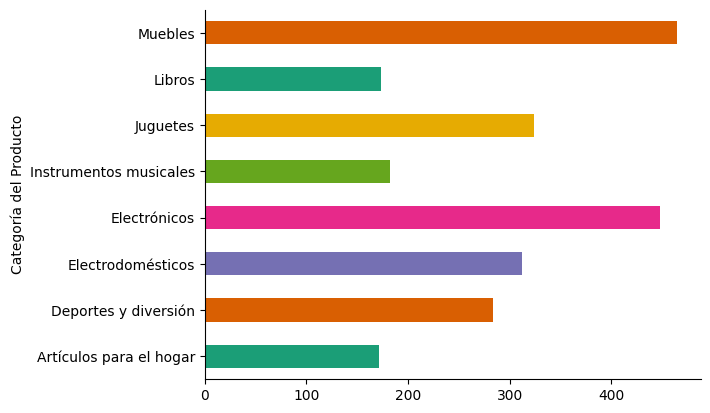

In [ ]:
# @title Categoría del Producto

from matplotlib import pyplot as plt
import seaborn as sns
tienda.groupby('Categoría del Producto').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

#1. Análisis de facturación



In [100]:
def sumaPrecios(nombre_tienda):
  precios = nombre_tienda.Precio.to_string(index=False)
  precios = precios.split()

  precios_formateados = [float(precios[n]) for n in range(len(precios))]

  suma = sum(precios_formateados)
  return suma


<function matplotlib.pyplot.show(close=None, block=None)>

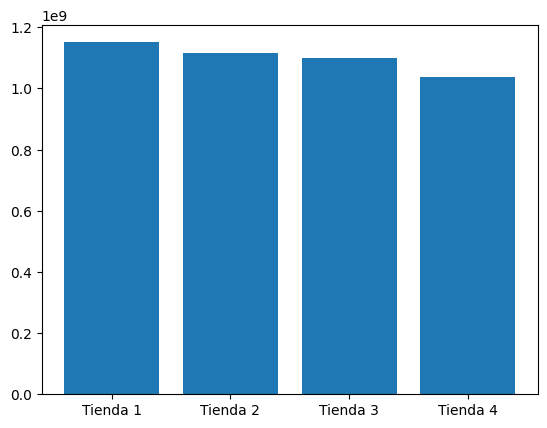

In [101]:
sumaTienda_1 = sumaPrecios(tienda)
sumaTienda_2 = sumaPrecios(tienda2)
sumaTienda_3 = sumaPrecios(tienda3)
sumaTienda_4 = sumaPrecios(tienda4)

sumas = [sumaTienda_1, sumaTienda_2,sumaTienda_3,sumaTienda_4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

plt.bar(x=nombres_tiendas, height=sumas)
plt.show

# 2. Ventas por categoría

In [107]:
def ventas_categoria(nombre_tienda):
  categorias = nombre_tienda['Categoría del Producto'].to_string(index=False)

  categoria_formateada = categorias.split()
  nueva_categoria = [str(valor) for n,valor in enumerate(categoria_formateada)]
  valores = ['para', 'el','Artículos','y','diversión','musicales']
  nueva_categoria = [palabra for palabra in categoria_formateada if palabra not in valores]
  categorias = ['Muebles', 'Electrónicos', 'Juguetes', 'Electrodomésticos', 'Deportes', 'Instrumentos', 'Libros', 'hogar']
  suma_categorias = {}

  for valor in nueva_categoria:
      if valor in categorias:
          if valor in suma_categorias:
              suma_categorias[valor] += 1
          else:
              suma_categorias[valor] = 1

  categorias = []
  cantidades = []

  for n in suma_categorias:
    categorias.append(n)
    cantidades.append(suma_categorias[n])


  resultados = [(categorias),(cantidades)]
  return resultados

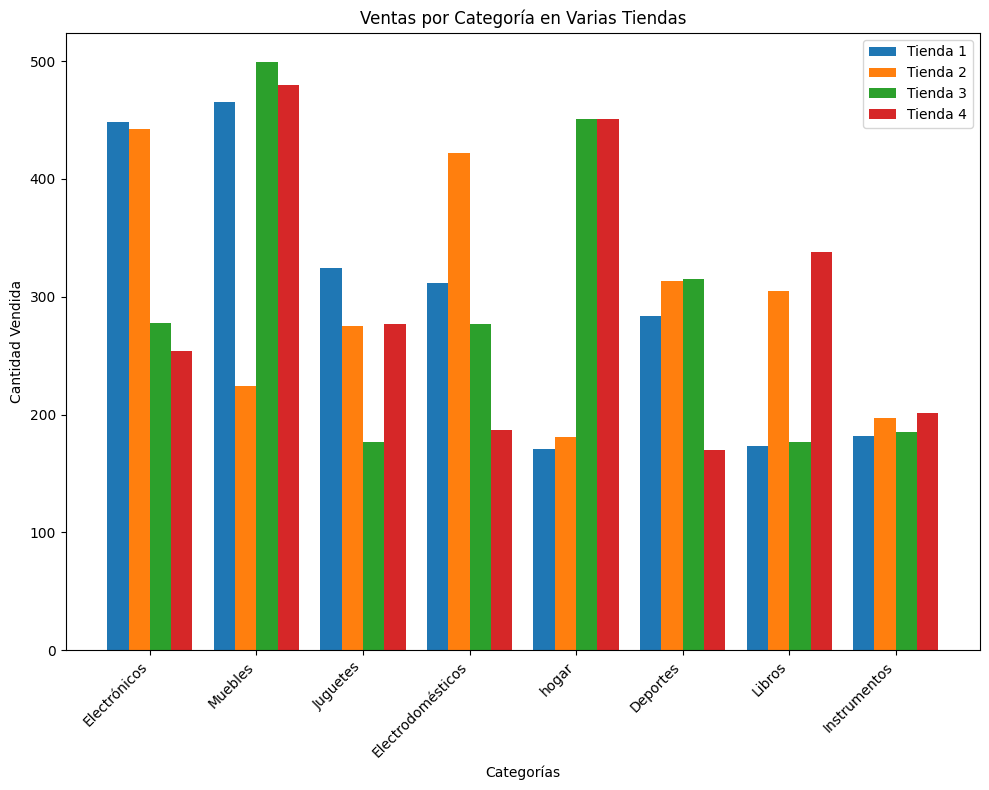

In [108]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

cantegorias1, cantidades1 = ventas_categoria(tienda)
cantegorias2, cantidades2 = ventas_categoria(tienda2)
cantegorias3, cantidades3 = ventas_categoria(tienda3)
cantegorias4, cantidades4 = ventas_categoria(tienda4)

x = np.arange(len(cantegorias1))

width = 0.2

plt.bar(x - 1.5*width, cantidades1, width, label='Tienda 1')
plt.bar(x - 0.5*width, cantidades2, width, label='Tienda 2')
plt.bar(x + 0.5*width, cantidades3, width, label='Tienda 3')
plt.bar(x + 1.5*width, cantidades4, width, label='Tienda 4')

plt.xticks(x, cantegorias1, rotation=45, ha='right')
plt.xlabel('Categorías')
plt.ylabel('Cantidad Vendida')
plt.title('Ventas por Categoría en Varias Tiendas')
plt.legend()
plt.tight_layout()

plt.show()



# 3. Calificación promedio de la tienda


In [ ]:
def promedioCalificaciones(nombre_tienda: object) -> float:
  estrellas = nombre_tienda['Calificación'].to_string(index=False)
  estrellas_formato = estrellas.split()
  estrellas_formato = [int(x) for x in estrellas_formato]
  suma = round((sum(estrellas_formato)/len(estrellas_formato)),2)
  return suma

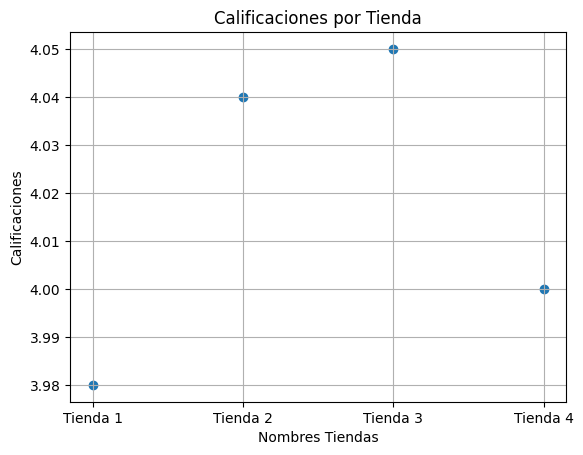

In [ ]:
calificacion_1 = promedioCalificaciones(tienda)
calificacion_2 = promedioCalificaciones(tienda2)
calificacion_3 = promedioCalificaciones(tienda3)
calificacion_4 = promedioCalificaciones(tienda4)

calificaciones = [calificacion_1, calificacion_2,calificacion_3,calificacion_4]
x_vals = range(len(nombres_tiendas))

plt.scatter(x_vals, calificaciones)

plt.xticks(ticks=x_vals, labels=nombres_tiendas)

plt.ylabel("Calificaciones")
plt.xlabel("Nombres Tiendas")
plt.title("Calificaciones por Tienda")
plt.grid(True)
plt.show()

# 4. Productos más y menos vendidos

In [34]:
def productos_mas_y_menos_vendidos(nombre_tienda):
  productos = nombre_tienda['Producto'].to_string(index=False)

  formato_productos = productos.splitlines()
  all_productos = {}
  for valor in formato_productos:
    if valor in all_productos:
      all_productos[valor] += 1
    else:
      all_productos[valor] = 1
  numeroMayor = 0
  numeroMenor = next(iter(all_productos.values()))
  producto_mas_vendido = ""
  producto_menos_vendido = ""
  for llave, valor in all_productos.items():
    if valor > numeroMayor:
      numeroMayor = valor
      producto_mas_vendido = llave

  for llave, valor in all_productos.items():
    if valor < numeroMenor:
      numeroMenor = valor
      producto_menos_vendido = llave

  resultados = [(producto_mas_vendido, numeroMayor), (producto_menos_vendido, numeroMenor)]
  productos_limpios = [(nombre.strip(), cantidad) for nombre, cantidad in resultados]
  return productos_limpios

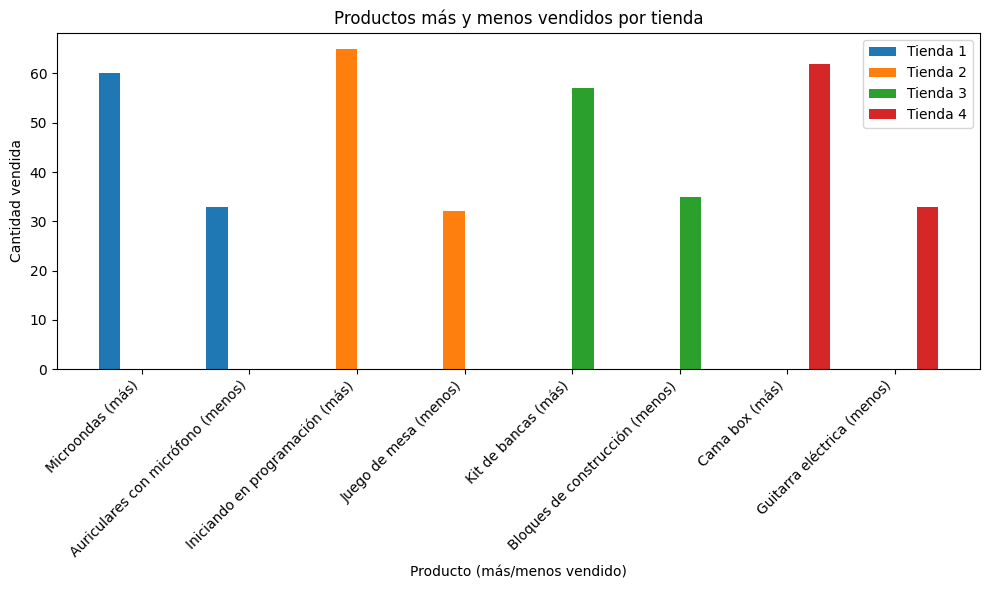

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Obtenemos los productos y cantidades
producto_mas_1, producto_menos_1 = productos_mas_y_menos_vendidos(tienda)
producto_mas_2, producto_menos_2 = productos_mas_y_menos_vendidos(tienda2)
producto_mas_3, producto_menos_3 = productos_mas_y_menos_vendidos(tienda3)
producto_mas_4, producto_menos_4 = productos_mas_y_menos_vendidos(tienda4)

# Productos y cantidades organizados por tienda
productos = [
    f'{producto_mas_1[0]} (más)', f'{producto_menos_1[0]} (menos)',
    f'{producto_mas_2[0]} (más)', f'{producto_menos_2[0]} (menos)',
    f'{producto_mas_3[0]} (más)', f'{producto_menos_3[0]} (menos)',
    f'{producto_mas_4[0]} (más)', f'{producto_menos_4[0]} (menos)',
]

cant_t1 = [producto_mas_1[1], producto_menos_1[1], 0, 0, 0, 0, 0, 0]
cant_t2 = [0, 0, producto_mas_2[1], producto_menos_2[1], 0, 0, 0, 0]
cant_t3 = [0, 0, 0, 0, producto_mas_3[1], producto_menos_3[1], 0, 0]
cant_t4 = [0, 0, 0, 0, 0, 0, producto_mas_4[1], producto_menos_4[1]]

x = np.arange(len(productos))  # índices para las posiciones
width = 0.2

# Crear la figura
plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, cant_t1, width, label='Tienda 1')
plt.bar(x - 0.5*width, cant_t2, width, label='Tienda 2')
plt.bar(x + 0.5*width, cant_t3, width, label='Tienda 3')
plt.bar(x + 1.5*width, cant_t4, width, label='Tienda 4')

# Etiquetas
plt.xticks(x, productos, rotation=45, ha='right')
plt.ylabel('Cantidad vendida')
plt.xlabel('Producto (más/menos vendido)')
plt.title('Productos más y menos vendidos por tienda')
plt.legend()
plt.tight_layout()
plt.show()



# 5. Envío promedio por tienda

In [94]:
def calculoEnvioPromedio(nombre_tienda):
  envio = nombre_tienda['Costo de envío'].to_string(index=False)
  envio_formateo = envio.splitlines()
  envio_int = [float(x) for x in envio_formateo]

  suma_envio = sum(envio_int)
  total_envios = len(envio_int)
  promedio_envio = suma_envio / total_envios

  return promedio_envio

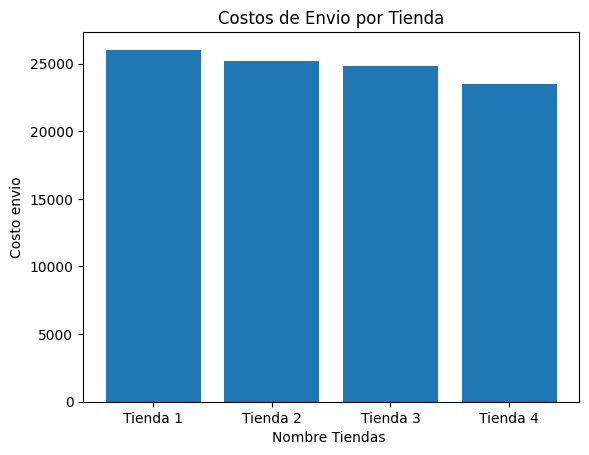

In [105]:
promedio_envio_1 = calculoEnvioPromedio(tienda)
promedio_envio_2 = calculoEnvioPromedio(tienda2)
promedio_envio_3 = calculoEnvioPromedio(tienda3)
promedio_envio_4 = calculoEnvioPromedio(tienda4)

promedios = [promedio_envio_1, promedio_envio_2, promedio_envio_3, promedio_envio_4]
plt.bar(x=nombres_tiendas, height=promedios)
plt.xlabel("Nombre Tiendas ")
plt.ylabel("Costo envio")
plt.title("Costos de Envio por Tienda")
plt.show()